In [1]:
# ===================== Imports & Settings =====================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# Load datasets
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
# Optional: Show all DataFrame columns in output
pd.set_option('display.max_columns', None)

In [4]:
# ===================== 1. Dataset Overview =====================

# Understand the structure of the movies and ratings data
print("Movies Dataset Info:")
display(movies.info())  # Shows column types, missing values, etc.
display(movies.head())  # Quick peek at the first few rows

print("\n Ratings Dataset Info:")
display(ratings.info())
display(ratings.head())

# - Check for missing values or incorrect datatypes
# - Verify we have enough user-movie interactions to build a recommender

Movies Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


None

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



 Ratings Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


None

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
# ===================== 2. Movies Dataset Exploration =====================

# Count how many unique movies we have
print(f"\nNumber of unique movies: {movies['movieId'].nunique()}")


Number of unique movies: 9742


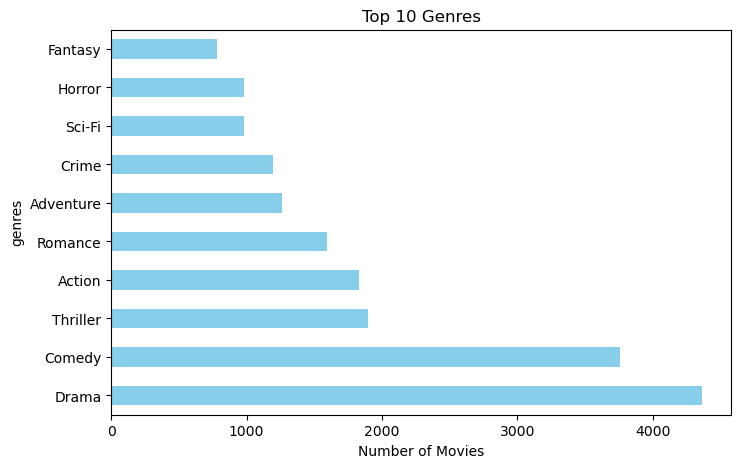

In [6]:
# Analyze most common genres
all_genres = movies['genres'].str.split('|').explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(8,5))
top_genres.plot(kind='barh', color='skyblue')
plt.title('Top 10 Genres')
plt.xlabel('Number of Movies')
plt.show()

# - Helps understand which genres dominate the dataset (e.g., Drama, Comedy)
# - Can guide genre-based filtering or weighting in recommendation models


Number of users: 610
Number of rated movies: 9724


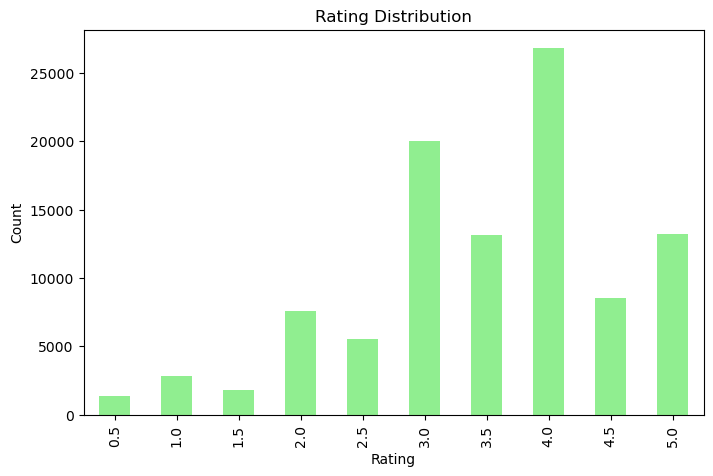

In [7]:
# ===================== 3. Ratings Dataset Exploration =====================

# How many users and unique movie ratings do we have
num_users = ratings['userId'].nunique()
num_movies_rated = ratings['movieId'].nunique()

print(f"\nNumber of users: {num_users}")
print(f"Number of rated movies: {num_movies_rated}")

# Visualize rating frequency (distribution)
plt.figure(figsize=(8,5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='lightgreen')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# - Ratings are skewed towards 3–5 stars, indicating positive bias
# - Could normalize or adjust scores in modeling to account for skewness

C:\Users\dewni\AppData\Local\Temp\ipykernel_20112\3999359241.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ratings.set_index('datetime')['rating'].resample('Y').count().plot(color='purple')


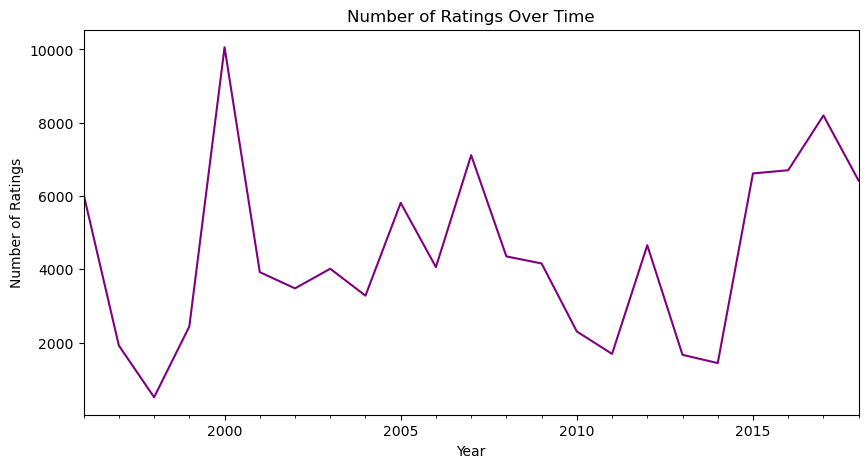

In [8]:
# ===================== 4. Ratings Over Time =====================

# Convert Unix timestamp to readable datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Resample by year to see activity trends
plt.figure(figsize=(10,5))
ratings.set_index('datetime')['rating'].resample('Y').count().plot(color='purple')
plt.title('Number of Ratings Over Time')
plt.ylabel('Number of Ratings')
plt.xlabel('Year')
plt.show()

# - Identify how user activity has changed over time
# - May affect recency-based recommendations or popularity weighting

In [9]:
# ===================== 5. Most Rated & Best Rated Movies =====================

# Top 10 most rated movies (by count)
most_rated = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)
most_rated_movies = movies[movies['movieId'].isin(most_rated.index)]
display(pd.merge(most_rated_movies, most_rated.rename('rating_count'), on='movieId'))

# Average rating for movies with at least 100 ratings
movie_stats = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['mean_rating', 'count_rating']
best_rated = movie_stats[movie_stats['count_rating'] >= 100].sort_values('mean_rating', ascending=False).head(10)
best_rated_movies = movies[movies['movieId'].isin(best_rated.index)]
display(pd.merge(best_rated_movies, best_rated, left_on='movieId', right_index=True))

# - "Most rated" movies are popular (useful for collaborative filtering)
# - "Best rated" movies (with sufficient votes) could be highlighted in UI
# - Outliers or extremely high-rated movies with low counts may be ignored

,movieId,title,genres,rating_count
0,110,Braveheart (1995),Action|Drama|War,237
1,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
4,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
5,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
6,527,Schindler's List (1993),Drama|War,220
7,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
8,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
9,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278


,movieId,title,genres,mean_rating,count_rating
46,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.237745,204
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317
659,858,"Godfather, The (1972)",Crime|Drama,4.289062,192
694,912,Casablanca (1942),Drama|Romance,4.240000,100
899,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.232394,142
914,1213,Goodfellas (1990),Crime|Drama,4.250000,126
922,1221,"Godfather: Part II, The (1974)",Crime|Drama,4.259690,129
2226,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218
6315,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.252336,107
6710,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,4.238255,149


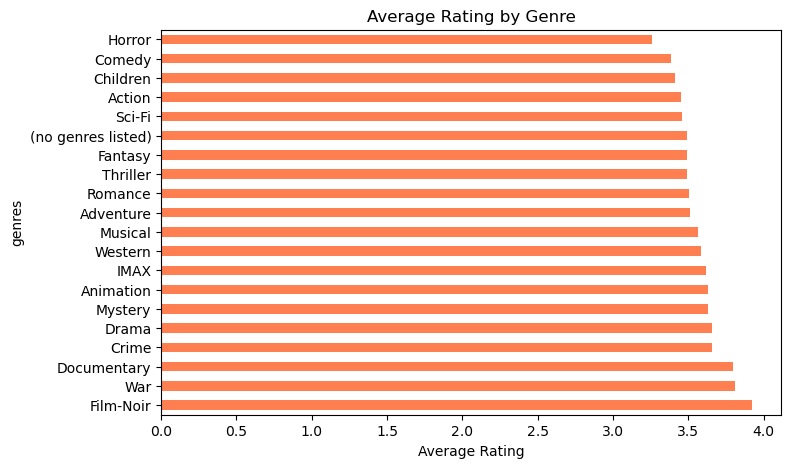

In [10]:
# ===================== 6. Genre-wise Average Rating =====================

# Explode genres to assign ratings to individual genres
movie_genres = movies[['movieId', 'genres']].copy()
movie_genres['genres'] = movie_genres['genres'].str.split('|')
genre_expanded = movie_genres.explode('genres')

# Join with ratings
genre_ratings = pd.merge(ratings, genre_expanded, on='movieId')

# Group and sort by average rating
genre_avg = genre_ratings.groupby('genres')['rating'].mean().sort_values(ascending=False)

# Visualize
plt.figure(figsize=(8,5))
genre_avg.plot(kind='barh', color='coral')
plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.show()

# - Tells which genres are generally rated higher
# - Can help personalize recommendations based on genre preferences